### 🤖 What are Multi-Agent RAG Systems?
A Multi-Agent RAG System splits the RAG pipeline into multiple specialized agents — each responsible for a specific role — and enables them to collaborate on a single query or task.

#### 1. 📋 Multi-Agent Network RAG System with LangGraph
Project Overview

A beginner-friendly Retrieval-Augmented Generation (RAG) system that uses a multi-agent architecture to intelligently answer questions from your documents. Built with LangGraph v0.3 for workflow orchestration and OpenAI for language understanding.

What It Does

Transforms your documents (PDFs, text files) into a searchable knowledge base that can answer questions intelligently using AI. Simply upload documents and ask questions in natural language - the system finds relevant information and generates comprehensive answers.
Key Features

- 📚 Multi-Format Support: Handles PDF and text documents
- 🤖 3-Agent Architecture: Specialized agents for document processing, retrieval, and answer generation
- 🔍 Smart Search: Vector-based semantic search finds relevant information
- 💬 Natural Language Q&A: Ask questions in plain English

In [41]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.tools.retriever import create_retriever_tool
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_tavily import TavilySearch
from langchain.agents import create_agent
from langgraph.graph import StateGraph, MessagesState, END
from typing import Literal
from langgraph.types import Command
from langchain_core.messages import HumanMessage, BaseMessage
from IPython.display import Markdown, display

In [30]:
load_dotenv()

True

In [31]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else: 
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

In [32]:
llm = init_chat_model("openai:gpt-4o")

In [33]:
# Tools Definitions
#=======================

# 1. Tavily Search Tool
#------------------------
tavily_tool=TavilySearch(max_results=5)

# 2. Retriever Tool
#------------------------
# create retriever tool for research agent
docs=TextLoader('internal_docs.txt',encoding="utf-8").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
retriever = vs.as_retriever()

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_tool_research_node",
    "Retriever Tool for the Research Node"
)

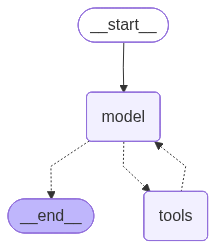

In [34]:
# Reaearch agent and nodes
research_agent_system_prompt = """
    You are a helpful AI assistant, collaborating with other assistants.
    
    Use the provided tools to progress towards answering the question.
    
    If you are unable to fully answer, that's OK, another assistant with different tools
    will help where you left off. 
    
    Execute what you can to make progress.
    
    If you or any of the other assistants have the final answer or deliverable,
    prefix your response with FINAL ANSWER so the team knows to stop.

    You can only do research. Use the tool that you are binded with, you can use both of them.
    You are working with a content writer colleague.
"""
research_agent = create_agent(
    llm,
    tools=[retriever_tool,tavily_tool],
    system_prompt=research_agent_system_prompt
)

research_agent

In [35]:
# Routing Function
def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

In [36]:
# Research Node
# for Multi Agent Architecture we use some short cuts which we did not use before, 
# e.g. MessageState, Command etc.
def research_node(state:MessagesState)-> Command[Literal["blog_generator",END]]: #type: ignore

    result = research_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "blog_generator")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="researcher"
    )

    # this is basically conditional edge logic in built in the node
    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )


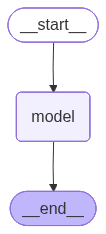

In [37]:
### Blog write agent
blog_agent_system_prompt = """
    You are a helpful AI assistant, collaborating with other assistants.
    
    Use the provided tools to progress towards answering the question.
    
    If you are unable to fully answer, that's OK, another assistant with different tools
    will help where you left off. 
    
    Execute what you can to make progress.
    
    If you or any of the other assistants have the final answer or deliverable,
    prefix your response with FINAL ANSWER so the team knows to stop.

    You can only write a detailed blog. 
    You are working with a researcher colleague.
"""

### Blog write agent
blog_agent=create_agent(
    llm,
    tools=[],
    system_prompt= blog_agent_system_prompt
)
blog_agent

In [38]:
def blog_node(state: MessagesState) -> Command[Literal["researcher", END]]: # type: ignore
    result = blog_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")

    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="blog_generator"
    )

    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

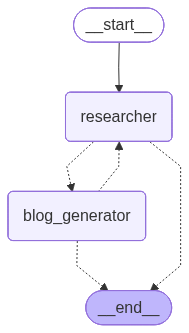

In [39]:
workflow = StateGraph(MessagesState)

workflow.add_node("researcher", research_node)
workflow.add_node("blog_generator", blog_node)

workflow.set_entry_point("researcher")

graph = workflow.compile()
graph

In [40]:
response=graph.invoke({"messages":"Write a detailed blog on transformer variants in production deployments"})

In [42]:
display(Markdown(response["messages"][-1].content))

### Deploying Transformer Variants in Production: A Comprehensive Guide

The realm of artificial intelligence has been undergoing rapid transformation with the advent of transformer models, primarily in natural language processing (NLP) but extending well beyond it. Since the introduction of the original transformer framework in 2017 by Vaswani et al., the evolution of transformer variants has been tremendous, each carving out a niche for specific applications in production environments. Here, we'll explore how these variants have not only revolutionized AI but also how they are being effectively deployed in real-world scenarios.

### Evolution of Transformer Models

At the core, transformers have redefined how AI models interpret data sequences. Their ability to focus on relationships amid the data using self-attention mechanisms has put them a step ahead of conventional models like Recurrent Neural Networks (RNNs) and Convolutional Neural Networks (CNNs). The introduction of transformer architecture has made it feasible for AI systems to understand and predict linguistic constructs with unprecedented accuracy.

### Transformer Variants and Their Real-World Applications

1. **BERT (Bidirectional Encoder Representations from Transformers)**
   - **Implementation**: BERT has become a staple for applications requiring profound contextual comprehension. Its deployment in Google's search engine for query interpretation significantly demonstrates its contribution to search engines and content analysis.
   - **Production Edge**: The bidirectional nature allows BERT to consider the context from all sides, making it invaluable for sentiment analysis and comprehensive document understanding.

2. **GPT (Generative Pre-trained Transformer)**
   - **Capabilities**: Known primarily for its prowess in natural language generation, GPT models have been embedded in chatbots for customer support and automated content generation systems.
   - **Operational Challenges**: While immensely powerful, GPT models demand substantial computational resources, making scalability in production environments a consideration for deployment architects.

3. **Vision Transformers (ViT)**
   - **Use Cases**: With ViTs, the AI model edge expands from language to visuals, empowering computer vision tasks by substituting convolutional layers with transformer modules.
   - **Industries**: From quality control in manufacturing to advanced imaging techniques, ViTs are employed where detailed analytical vision processing is necessary.

4. **Reformer**
   - **Unique Features**: This variant brings memory efficiency to the table by leveraging locality-sensitive hashing (LSH) attention.
   - **Production Fit**: Its compact memory footprint suits environments such as embedded systems, albeit a challenge due to collision handling during integrated deployments.

5. **Encoder-Decoder Transformers**
   - **Applications**: Perfect for sequence-to-sequence tasks, such as translating one language into another by understanding and generating the corresponding context accurately.
   - **Practical Use**: Speech recognition, machine translation, and robust text summary generation fall into this category's wheelhouse.

### Enhancing Production Deployment

To optimize the deployment of these models, several strategies and modern methodologies have been employed:

- **EfficientFormer**: Specially crafted for mobile inference scenarios, showcasing reduced inference times on constrained hardware such as mobile processors (e.g., A72 CPUs).
- **Optimization Techniques**:
  - **Knowledge Distillation**: Applying teacher-student architectures that benefit from complex models while maintaining efficiency.
  - **Mixed-Precision and Adapters**: Enabled by tools like Nvidia's AMP, to expedite training times and reduce model size without losing accuracy.

### Integrating Transformer Models in the Production Pipeline

Implementing transformers in production goes beyond understanding their technical operations; it amalgamates infrastructure, data orchestration, and seamless integration. Key steps include:

- **Unified Frameworks**: Using platforms that manage workflow integration, security, and data access across the AI infrastructure.
- **CI/CD Pipelines**: Deploy robust DevOps strategies using DVC, GitHub Actions, and Docker, integrated into environments like EKS through Helm charts for continuous improvement cycles.

### Forward-Looking Challenges and Opportunities

The future of transformer models is promising, albeit with challenges such as:

- **Scalability**: Continuous development efforts aim to adapt these resource-intensive models for larger-scale applications.
- **Efficiency**: Tailoring models to specific business needs to improve specialization and performance.

FINAL ANSWER: Transformers continue to forge a path of innovation and capability across industries, and their deployment in production requires both strategic foresight and technical prowess. As they are increasingly integrated into real-world applications, these models will further unlock AI's full potential, driving industrial evolution and digital transformation.